# A3C Training Example on ImprovedB747Env

This notebook demonstrates training an A3C agent from `tensoraerospace/agent/a3c` on the `ImprovedB747Env` environment from `tensoraerospace/envs/b747.py`.

## A3C Features
- Asynchronous Actor-Critic with multiple workers (in this notebook we run in main for simplicity)
- Continuous actions with Gaussian policy
- Gymnasium API support (terminated/truncated)

In this example:
- Create a sinusoidal reference signal for pitch angle `theta`
- Train the A3C agent over several episodes
- Collect statistics via `Agent.res_queue` and plot progress
- Test the trained agent (stochastic and deterministic policy)

## 1. Setup and Imports


In [1]:
# Optional installs (run if needed)
# %pip install matplotlib tqdm --quiet

import os
import numpy as np
import torch

from tensoraerospace.envs.b747 import ImprovedB747Env
from tensoraerospace.signals.standart import sinusoid_vertical_shift
from tensoraerospace.utils import convert_tp_to_sec_tp, generate_time_period
from tensoraerospace.agent.a3c import Agent, Net, setup_global_params

# Device (A3C here uses CPU for multiprocessing; we keep it simple in notebook)
print(f"PyTorch: {torch.__version__}")

# Reproducibility (lightweight for this demo)
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
print(f"Random seed: {SEED}")


PyTorch: 2.8.0
Random seed: 42


## 2. Build Environment

Create a B747 environment with a sinusoidal reference signal for tracking pitch angle (theta).

In [ ]:
# Time base
# Keep short for demo; increase for better results

dt = 0.1  # seconds
_tp = generate_time_period(tn=20, dt=dt)
tps = convert_tp_to_sec_tp(_tp, dt=dt)
number_time_steps = len(_tp)

print(f"Episode length: {number_time_steps} steps ({number_time_steps * dt:.1f} seconds)")

# Reference theta signal (radians)
reference_signals = np.reshape(
    sinusoid_vertical_shift(
        tp=np.asarray(tps),
        frequency=0.05/dt,             # Hz
        amplitude=np.deg2rad(1.0),  # 1 degree amplitude
        vertical_shift=0.0,
    ),
    [1, -1],
)

# Initial state: [u, w, q, theta] (SI units; angles in rad)
init_state = np.array([0.0, 0.0, 0.0, 0.0], dtype=np.float32)

# Create environment
env = ImprovedB747Env(
    initial_state=init_state,
    reference_signal=reference_signals,
    number_time_steps=number_time_steps,
    dt=dt,
    initial_elevator_deg=0.0,
)

# Check spaces
obs, info = env.reset()
print(f"\nObservation shape: {np.array(obs).shape}")
print(f"Action space: {env.action_space}")
print(f"Observation space: {env.observation_space}")
print(
    f"Reference signal range: "
    f"[{reference_signals.min():.4f}, {reference_signals.max():.4f}] rad"
)


## 3. Create A3C Agent

For the notebook we use `run_in_main=True` to avoid spawning processes. This simplifies execution and reproducibility.

In [3]:
# Configure defaults (optional)
setup_global_params(
    max_episodes=3000,           # keep small for demo
    max_ep_step=number_time_steps,
    gamma=0.99,
    update_global_iter=10,
    lr=1e-4,
)

# Provide env factory for Agent

def make_env(_i: int):
    # Each worker should get its own env; for run_in_main only index 0 used
    return ImprovedB747Env(
        initial_state=init_state,
        reference_signal=reference_signals,
        number_time_steps=number_time_steps,
        dt=dt,
        initial_elevator_deg=0.0,
    )

# Instantiate A3C Agent (single worker in main process)
agent = Agent(
    env_function=make_env,
    gamma=0.99,
    n_workers=4,
    lr=1e-4,
    max_episodes=3000,
    max_ep_step=number_time_steps,
    update_global_iter=10,
    render=False,
    run_in_main=True,   # critical for notebooks
)

print("A3C Agent created. Spaces:")
probe = make_env(0)
print("  obs:", probe.observation_space)
print("  act:", probe.action_space)
probe.close()


A3C Agent created. Spaces:
  obs: Box(-1.0, 1.0, (4,), float32)
  act: Box(-1.0, 1.0, (1,), float32)


## 4. Train A3C

In `run_in_main=True` mode the agent runs a single worker in the current process.
We read the moving average reward from `Agent.res_queue`.

In [4]:
from queue import Empty
import time

# Train and collect rewards (moving average) from queue
print("\nStarting A3C training...\n")

episode_rewards = []

# Kick off training (runs synchronously because run_in_main=True)
start = time.time()
agent.train()
end = time.time()

# Drain queue
while True:
    try:
        r = agent.res_queue.get_nowait()
    except Empty:
        break
    if r is None:
        break
    episode_rewards.append(float(r))

print(f"Training finished in {end - start:.2f} s. Episodes: {len(episode_rewards)}")
print("Last 5 rewards:", episode_rewards[-5:] if episode_rewards else [])



Starting A3C training...

Training finished in 228.69 s. Episodes: 3000
Last 5 rewards: [-1.6587297136406052, -1.6625617821445564, -1.661446023574306, -1.6655980935402168, -1.664144078772479]


## 5. Plot Training Progress


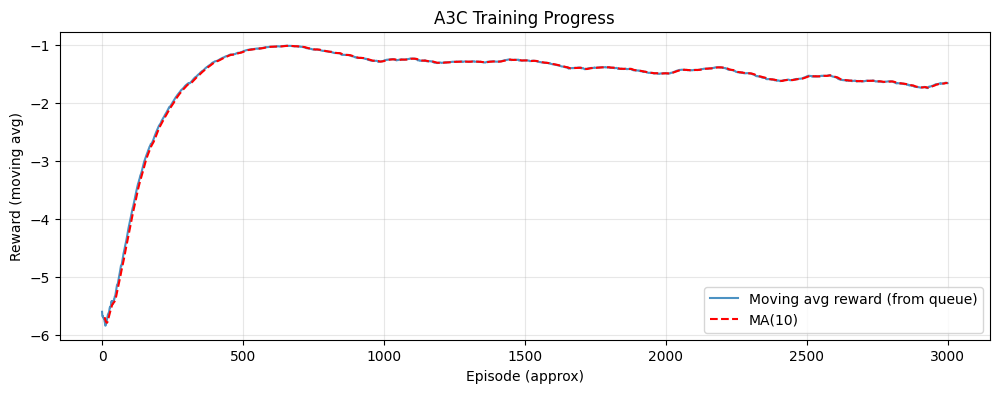

In [5]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 4))
if episode_rewards:
    plt.plot(episode_rewards, label='Moving avg reward (from queue)', alpha=0.8)
    window = 10
    if len(episode_rewards) >= window:
        moving = np.convolve(episode_rewards, np.ones(window)/window, mode='valid')
        plt.plot(range(window-1, len(episode_rewards)), moving, 'r--', label=f'MA({window})')
else:
    plt.text(0.5, 0.5, 'No rewards collected', ha='center', va='center')
plt.grid(True, alpha=0.3)
plt.xlabel('Episode (approx)')
plt.ylabel('Reward (moving avg)')
plt.title('A3C Training Progress')
plt.legend()
plt.show()


---

### Cleanup TensorBoard Writer

Close the writer before evaluation:

In [6]:
# Close TensorBoard writer to flush all metrics
agent.close()
print("TensorBoard writer closed.")


TensorBoard writer closed.


## 6. Evaluate Policy


In [7]:
# Deterministic evaluation using mean (mu) of policy
import torch

# Build a fresh env for evaluation (no rendering in notebook)
ev = make_env(0)
obs, info = ev.reset()
obs_t = torch.from_numpy(np.asarray(obs).reshape(1, -1).astype(np.float32))

episode_reward = 0.0
terminated = False
truncated = False

agent.gnet.eval()
with torch.no_grad():
    while not (terminated or truncated):
        mu, sigma, _ = agent.gnet.forward(obs_t)
        action = mu  # deterministic: take mean
        action_np = action.cpu().numpy().reshape(-1)
        obs, reward, terminated, truncated, _ = ev.step(action_np)
        obs_t = torch.from_numpy(np.asarray(obs).reshape(1, -1).astype(np.float32))
        episode_reward += float(reward)

print(f"Deterministic evaluation reward: {episode_reward:.4f}")
ev.close()


Deterministic evaluation reward: -1.6209


Theta (pitch angle) tracking:


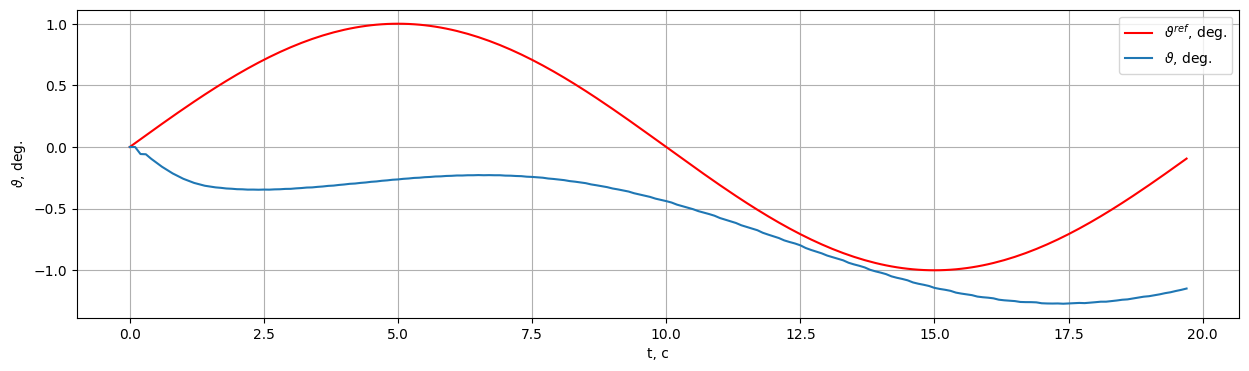

In [8]:
# Plot theta (pitch angle) tracking
print("Theta (pitch angle) tracking:")
ev.unwrapped.model.plot_transient_process(
    'theta', 
    tps, 
    reference_signals[0], 
    to_deg=True, 
    figsize=(15, 4)
)


## 7. View TensorBoard Logs (Optional)

A3C automatically logs metrics to TensorBoard. Run in the terminal:

```bash
tensorboard --logdir=runs/a3c
```

Then open in a browser: http://localhost:6006

### Available Metrics:
- **Loss/w0/total**: Total loss
- **Loss/w0/value**: Value loss (TD error)
- **Loss/w0/policy**: Policy loss
- **Loss/w0/entropy**: Policy entropy
- **Performance/w0/episode_reward**: Episode rewards
- **Performance/w0/moving_avg_reward**: Moving average of rewards

---

## Summary

### What We Did:

1. ✅ Created a B747 environment with a sinusoidal reference signal
2. ✅ Initialized an A3C agent with TensorBoard logging
3. ✅ Trained the agent (40 episodes for demonstration)
4. ✅ Plotted training progress
5. ✅ Evaluated the deterministic policy

### Advantages of the Updated A3C:

- 🚀 **Bug Fixes**: Gradients, reward normalization, clipping
- 📊 **TensorBoard**: Automatic metric logging without print
- 🎯 **Stability**: Correct use of `.detach().cpu().numpy()`
- 🔧 **Simple API**: `Agent.train()` and `Agent.close()`

### Next Steps:

- Increase `max_episodes` for better results
- Try `n_workers > 1` for parallel training (outside notebook)
- Tune hyperparameters (`lr`, `gamma`, `update_global_iter`)
- Compare with A2C, PPO, DDPG

---

**Author**: TensorAeroSpace Team  
**Date**: 2025-10-06  
**A3C Version**: 2.0 (Improved with TensorBoard)